# CPU price predictions using ML models

## Project Description
This project analyzed CPU data using supervised and unsupervised machine learning. For price prediction, Polynomial Ridge Regression was the top performer. A Decision Tree model classified CPUs into performance categories effectively. For grouping similar CPUs, K-Means clustering yielded the best results. Each model served its specific purpose, providing insights into CPU characteristics and pricing.

## Library imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer, f1_score
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, classification_report, accuracy_score
from sklearn.decomposition import PCA

## Dataset import

[The preprocessed and cleaned dataset](https://drive.google.com/file/d/12g2ODrOilcjaCYL2LFidtxnNPVql1xBL/view?usp=sharing)

In [ ]:
share_url = "https://drive.google.com/file/d/13IT8yNlv1j75Wn4-c2wVNC7ai5-MH1qr/view?usp=sharing"
download_url  = "https://drive.google.com/uc?export=download&id="+share_url.split("/")[-2]
data = pd.read_csv(download_url)
data.head(20)

,processor,frequency,maximum_frequency,cores,threads,codename,package,single_core_score,multi_core_score,tdp,price_usd,platform,price_amd
0,AMD Ryzen 9 9950X3D,4300.0,5700.0,16,32,Granite Ridge,AM5,3397,22122,65 W,643.977,desktop,245999.21
1,AMD Ryzen 9 9950X,4300.0,5700.0,16,32,Granite Ridge,AM5,3385,21426,170 W,559.980,desktop,213912.36
2,AMD Ryzen 7 9700X,3800.0,5500.0,8,16,Granite Ridge,AM5,3351,16994,65 W,309.000,desktop,118038.00
3,AMD Ryzen 5 9600X,3900.0,5400.0,6,12,Granite Ridge,AM5,3345,15039,65 W,198.000,desktop,75636.00
4,AMD Ryzen 9 9900X,4400.0,5600.0,12,24,Granite Ridge,AM5,3341,19828,120 W,395.560,desktop,151103.92
5,AMD Ryzen 7 9800X3D,4700.0,5200.0,8,16,Granite Ridge,AM5,3333,18334,120 W,449.000,desktop,171518.00
6,AMD Ryzen 9 9900X3D,4400.0,5500.0,12,24,Granite Ridge,AM5,3293,20212,120 W,569.000,desktop,217358.00
7,Intel Core i9-14900KS,3200.0,6200.0,24,32,Raptor Lake,LGA1700,3238,23166,150 W,599.000,desktop,228818.00
8,AMD Ryzen 5 9600,3800.0,5200.0,6,12,Granite Ridge,AM5,3220,14461,65 W,198.000,desktop,75636.00
9,Intel Core Ultra 9 285K,3700.0,5700.0,24,24,Arrow Lake,LGA1851,3213,22704,125 W,539.990,desktop,206276.18


### Scatter plots of different Price (USD) based on different features

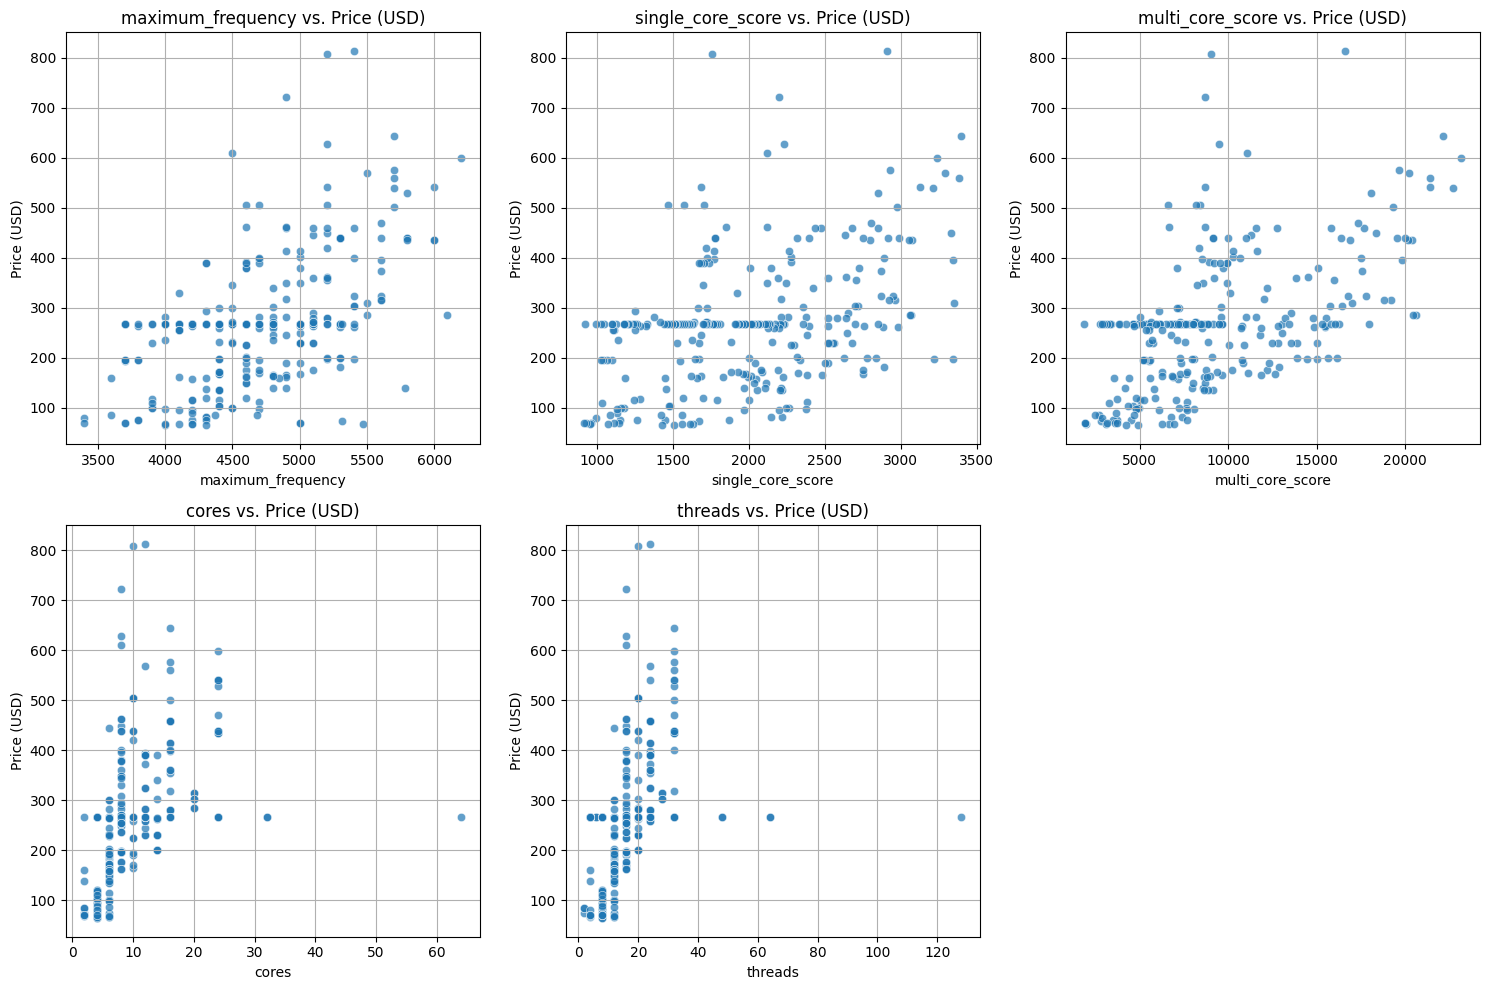

In [ ]:
features_to_plot = ['maximum_frequency', 'single_core_score', 'multi_core_score', 'cores', 'threads']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.scatterplot(x=data[feature], y=data['price_usd'], alpha=0.7)
    plt.title(f'{feature} vs. Price (USD)')
    plt.xlabel(feature)
    plt.ylabel('Price (USD)')
    plt.grid(True)

plt.tight_layout()
plt.show()

## The correlation matrix and heatmap

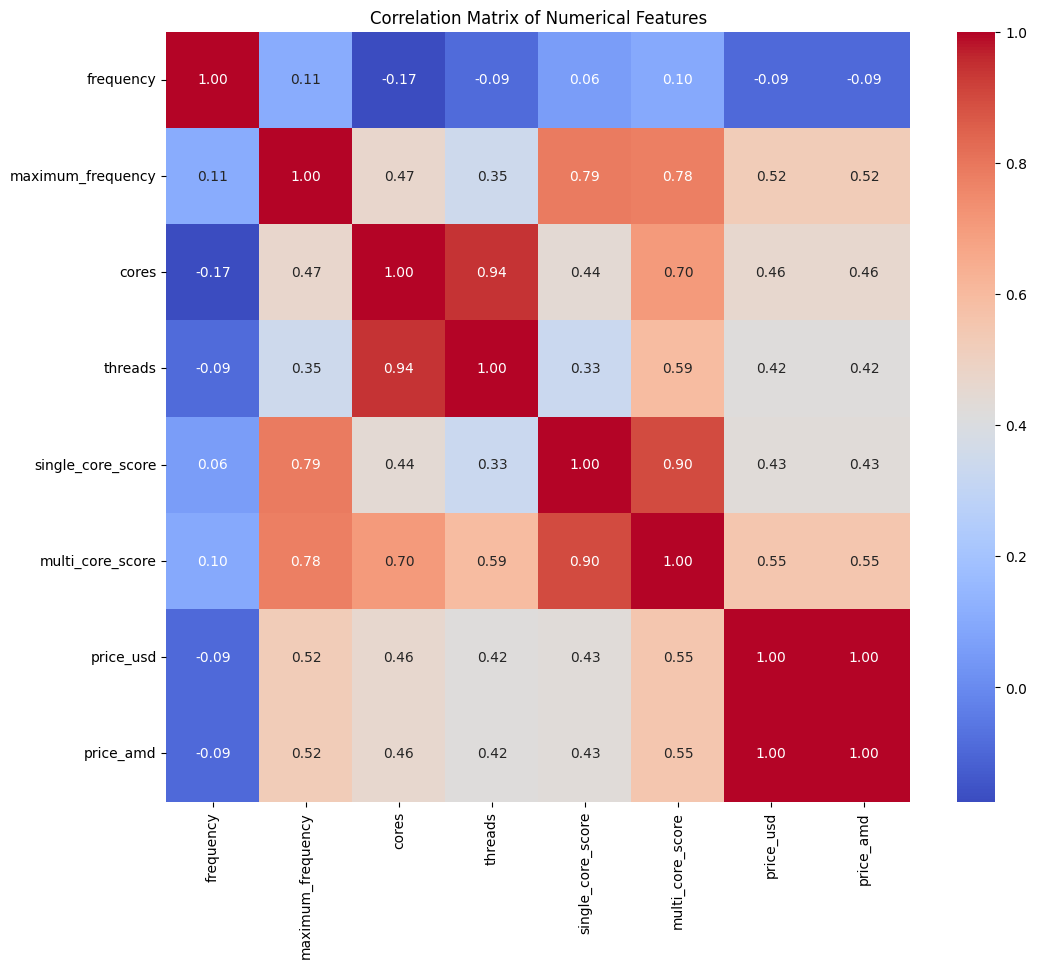

In [ ]:
correlation_matrix = data.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Regression models

### Task Description
The goal of this section is to build and evaluate different regression models to predict the price of CPUs based on their features. This involves selecting appropriate features, training various regression algorithms (e.g., Ridge Regression, Polynomial Regression, SVR), optimizing their hyperparameters, and comparing their performance using metrics like MSE, RMSE, MAE, and R-squared.

### Ridge Linear Regression model

Feature selection

In [ ]:
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()
features = data[numerical_cols].drop(columns=['price_usd', 'price_amd'], errors='ignore')
target = data['price_usd']

Splitting the data into train and test sets, and also scaling them

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training the `linear regression` model

In [ ]:
model = Ridge(alpha=1)  # alpha can be tuned later with Grid Search
model.fit(X_train_scaled, y_train)

Ridge(alpha=1)

Making the prediction based on the **test** data

In [ ]:
y_pred = model.predict(X_test_scaled)

Evaluating the `linear regression` model using `MSE` and `R squared score`

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R-squared: {r2:.2f}')

Mean Squared Error: 12841.10
Root Mean Squared Error: 113.32
Mean Absolute Error: 86.30
R-squared: 0.33


Displaying the coefficients

In [ ]:
coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_})
print('\nModel Coefficients:')
display(coefficients)


Model Coefficients:


,Feature,Coefficient
0,frequency,-37.564694
1,maximum_frequency,58.137451
2,cores,-100.739489
3,threads,76.906252
4,single_core_score,-90.234657
5,multi_core_score,136.819080


#### Actual vs Predicted Prices Plot

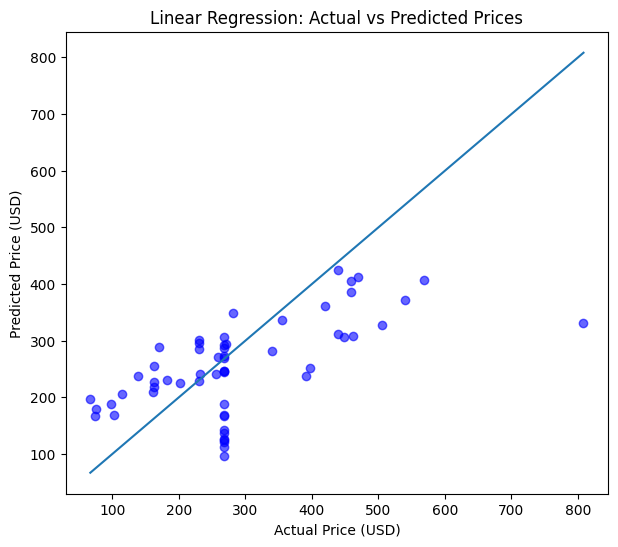

In [ ]:
# Linear Regression predictions (y_pred is already calculated from cell u2gEm-L_FtSn)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title("Linear Regression: Actual vs Predicted Prices")

# Ideal fit line (y=x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

#### Grid search for Linear Regression

Grid Search is used to select the optimal Ridge regularization parameter (alpha) using 5-fold cross-validation.

* `param_grid`: This dictionary defines the range of hyperparameters that `GridSearchCV` will explore. In this case, it's tuning the `alpha` parameter for the Ridge model, which controls the strength of the regularization. The values `[0.01, 0.1, 0.5, 1, 10, 100]` are the specific alpha values to be tested.

* `grid = GridSearchCV(...)`: This initializes the GridSearchCV object
* `grid.fit(X_train_scaled, y_train)`: This command runs the grid search process.
* `best_ridge = grid.best_estimator_`: After `grid.fit()` completes, this line retrieves the Ridge model that performed the best according to the `neg_mean_squared_error` metric during cross-validation. This `best_ridge` model is then ready to be used for predictions on unseen data (the test set).

In [ ]:
param_grid = {
    "alpha": [0.01, 0.1, 0,5, 1, 10, 100]  # regularization strength
}

grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid.fit(X_train_scaled, y_train)

# Best model
best_ridge = grid.best_estimator_


Than the model's accuracy is calculated

In [ ]:
y_pred = best_ridge.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print("Grid Search Ridge Regression Results:")
print(f"Best alpha: {grid.best_params_['alpha']}")
print(f'Mean Squared Error: {mse:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R-squared: {r2:.2f}')

Grid Search Ridge Regression Results:
Best alpha: 0
Mean Squared Error: 13039.49
Root Mean Squared Error: 114.19
Mean Absolute Error: 87.33
R-squared: 0.32


On the test set, the **optimized** model’s performance was **similar** to the **unoptimized** version. This is expected because cross-validation selects the best parameter for the training folds, which may not always lead to a lower error on the held-out test set, especially for small datasets or when the optimal alpha is already very small.

#### Random Search for Linear Regression

Randomized Search is used to efficiently find optimal hyperparameters. Unlike Grid Search, which tries every combination in a predefined grid, Randomized Search samples a fixed number of parameter settings from a specified distribution. This approach is more efficient for large search spaces, as it can often find a good set of hyperparameters faster than exhaustively searching every possibility. In this case, `np.logspace(-4, 3, 1000)` creates 1000 logarithmically spaced `alpha` values for the Ridge model, and `n_iter=50` means only 50 of these will be randomly sampled and tested.

In [ ]:
param_dist = {"alpha": np.logspace(-4, 3, 1000)}

random_search = RandomizedSearchCV(
    Ridge(),
    param_distributions=param_dist,
    n_iter=50,  # try 50 random alpha values
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42
)

random_search.fit(X_train_scaled, y_train)

# Best model
best_ridge_random = random_search.best_estimator_

In [ ]:
y_pred = best_ridge_random.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Random Search Ridge Regression Results:")
print(f"Best alpha: {random_search.best_params_['alpha']}")
print(f'Mean Squared Error: {mse:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R-squared: {r2:.2f}')

Random Search Ridge Regression Results:
Best alpha: 0.0002590677858688009
Mean Squared Error: 13039.41
Root Mean Squared Error: 114.19
Mean Absolute Error: 87.33
R-squared: 0.32


As we can see the results are the same, so it is not efficient to use `Linear Regression`

### Polynomial Regression model

We can also try other `Regression models`, so that we can determine which of them is the best. At first we will try the `Polynomial regression`

 Training the `polynomial regression` model

This code block sets up a `Polynomial Ridge Regression` model using a `Pipeline`

  **Pipeline Creation**: A `Pipeline` is created to streamline the workflow. It combines two steps:

  *   **`PolynomialFeatures(include_bias=False)`**: This transforms the original features into polynomial features (e.g., if you have feature `x`, it creates `x^2`, `x^3`, etc.). `include_bias=False` prevents adding an intercept term as `Ridge` will handle it.
  *   **`Ridge()`**: This is the Ridge Regression model, which adds L2 regularization to prevent overfitting by penalizing large coefficients.

In [ ]:
# ---- Polynomial + Ridge Pipeline ----
poly_ridge_pipeline = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("ridge", Ridge())
])

Accuracy evaluation

Mean Squared Error: 13039.41
Root Mean Squared Error: 114.19
Mean Absolute Error: 87.33
R-squared: 0.32


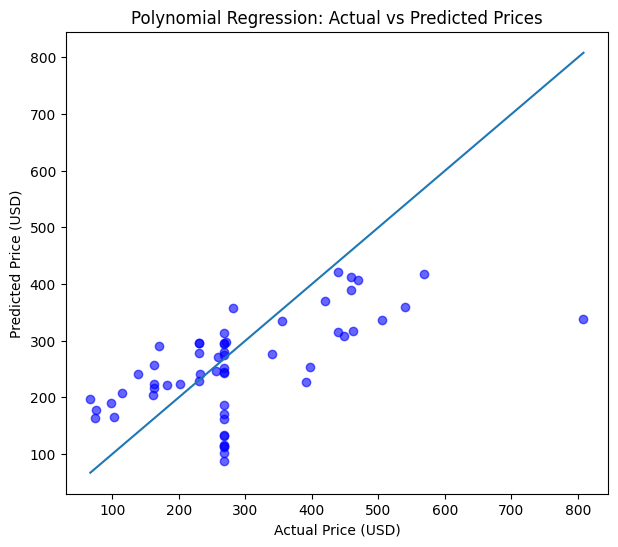

In [ ]:
y_pred_ridge = best_ridge_random.predict(X_test_scaled)  # or best_ridge if you kept it after fitting

mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_ridge)
r2 = r2_score(y_test, y_pred_ridge)

print(f'Mean Squared Error: {mse:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R-squared: {r2:.2f}')

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_ridge, color='blue', alpha=0.6)
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title("Polynomial Regression: Actual vs Predicted Prices")

# Add ideal fit line
min_val = min(y_test.min(), y_pred_ridge.min())
max_val = max(y_test.max(), y_pred_ridge.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

#### Grid Search for Polynomial

Grid Search was used to select the optimal combination of polynomial degree and Ridge regularization parameter (alpha) using 5-fold cross-validation.

In [ ]:
# Define grid of hyperparameters
param_grid = {
    "poly__degree": [2, 3, 4],
    "ridge__alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    poly_ridge_pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid.fit(X_train_scaled, y_train)

# Best model from grid search
best_poly_ridge_grid = grid.best_estimator_

In [ ]:
y_pred_grid = best_poly_ridge_grid.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred_grid)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_grid)
r2 = r2_score(y_test, y_pred_grid)

print("Grid Search Polynomial Ridge Regression Results:")
print(f"Best parameters: {grid.best_params_}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

Grid Search Polynomial Ridge Regression Results:
Best parameters: {'poly__degree': 2, 'ridge__alpha': 0.01}
MSE: 12955.76
RMSE: 113.82
MAE: 84.34
R²: 0.32


#### Random Search for Polynomial

Random Search was used to select the optimal combination of polynomial degree and Ridge regularization parameter (alpha) using 5-fold cross-validation.

In [ ]:
# Define random hyperparameter distributions
param_dist = {
    "poly__degree": [2, 3, 4, 5],
    "ridge__alpha": np.logspace(-4, 3, 1000)  # 0.0001 to 1000
}

random_search = RandomizedSearchCV(
    poly_ridge_pipeline,
    param_distributions=param_dist,
    n_iter=50,  # try 50 random combinations
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42
)

random_search.fit(X_train_scaled, y_train)

# Best model from random search
best_poly_ridge_random = random_search.best_estimator_

In [ ]:
y_pred_random = best_poly_ridge_random.predict(X_test_scaled)

poly_mse = mean_squared_error(y_test, y_pred_random)
poly_rmse = np.sqrt(mse)
poly_mae = mean_absolute_error(y_test, y_pred_random)
poly_r2 = r2_score(y_test, y_pred_random)

print("Random Search Polynomial Ridge Regression Results:")
print(f"Best parameters: {random_search.best_params_}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R-squared: {r2:.2f}")

Random Search Polynomial Ridge Regression Results:
Best parameters: {'ridge__alpha': np.float64(0.003009390034449721), 'poly__degree': 2}
MSE: 12955.76
RMSE: 113.82
MAE: 84.34
R-squared: 0.32


### Support Vector Regression (SVR) Model

First of all let's define a function, that will train the model based on `train-test` data, and evaluate its accuracy

In [ ]:
def train_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'\n--- {model_name} ---\n')
    print(f'Mean Squared Error: {mse:.2f}')
    print(f'Root Mean Squared Error: {rmse:.2f}')
    print(f'Mean Absolute Error: {mae:.2f}')
    print(f'R-squared: {r2:.2f}')
    return mse, r2, rmse, mae

Training the `Support Vector Regression` model using the scaled training data.

In [ ]:
# Initialize and train the SVR model
svr_model = SVR()

# The train_evaluate_model function expects scaled X and original y
svr_mse, svr_r2, svr_rmse, svr_mae = train_evaluate_model(svr_model, X_train_scaled, y_train, X_test_scaled, y_test, 'Support Vector Regressor')


--- Support Vector Regressor ---

Mean Squared Error: 18387.93
Root Mean Squared Error: 135.60
Mean Absolute Error: 91.99
R-squared: 0.03


As we can see the `R-squared = 0.03`, which is near 0. That means that `Support Vector Regression` can't be used for predictions.

The visualisation of `Actual vs Predicted Prices` of `Support Vector Regression`

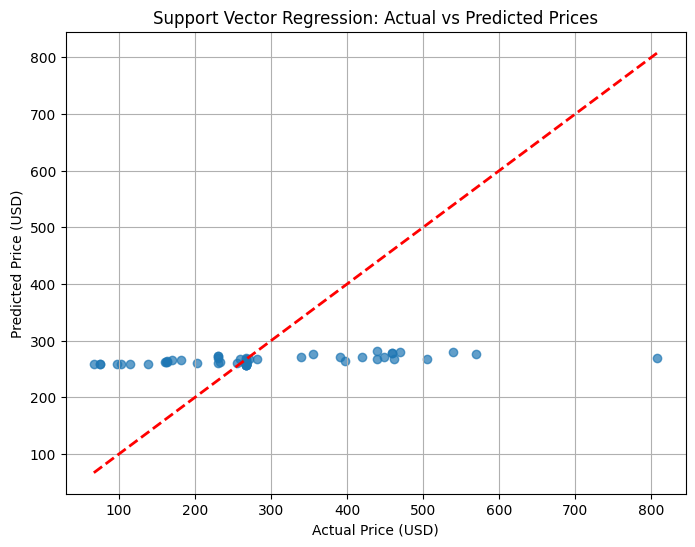

In [ ]:
# Predict on test data using the trained SVR model
y_pred_svr = svr_model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr, alpha=0.7)
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title("Support Vector Regression: Actual vs Predicted Prices")

# Ideal fit line
min_val_svr = min(y_test.min(), y_pred_svr.min())
max_val_svr = max(y_test.max(), y_pred_svr.max())
plt.plot([min_val_svr, max_val_svr], [min_val_svr, max_val_svr], 'r--', lw=2)

plt.grid(True)
plt.show()

### Model Comparison Table

Now we can create a `model comparison table`, to determine which of the regression models performed the best

In [ ]:
# Initialize an empty DataFrame to store results
results = pd.DataFrame(columns=['Model', 'MSE', 'RMSE', 'MAE', 'R-squared'])

# Add Ridge Regression results (from best_ridge_random predictions)
ridge_results = pd.DataFrame([{
    'Model': 'Ridge Regression',
    'MSE': mse,      # mse from Ridge model
    'RMSE': rmse,    # rmse from Ridge model
    'MAE': mae,      # mae from Ridge model
    'R-squared': r2  # r2 from Ridge model
}])
results = pd.concat([results, ridge_results], ignore_index=True)

# Add Polynomial Ridge Regression results (from Random Search best model)
poly_ridge_results = pd.DataFrame([{
    'Model': 'Polynomial Ridge Regression',
    'MSE': poly_mse,
    'RMSE': poly_rmse,
    'MAE': poly_mae,
    'R-squared': poly_r2
}])
results = pd.concat([results, poly_ridge_results], ignore_index=True)

#SVR results
svr_results = pd.DataFrame([{
    'Model': 'Support Vector Regressor',
    'MSE': svr_mse,
    'RMSE': svr_rmse,
    'MAE': svr_mae,
    'R-squared': svr_r2
}])
results = pd.concat([results, svr_results], ignore_index=True)

# Display the comprehensive comparison
print('\nComprehensive Model Comparison:')
display(results)



Comprehensive Model Comparison:


/tmp/ipython-input-2315472780.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, ridge_results], ignore_index=True)


,Model,MSE,RMSE,MAE,R-squared
0,Ridge Regression,12955.763153,113.823386,84.335819,0.319560
1,Polynomial Ridge Regression,12974.427261,113.823386,84.311954,0.318580
2,Support Vector Regressor,18387.932413,135.602111,91.991286,0.034261


In [ ]:
# Sort by MSE, RMSE, MAE (ascending) and R-squared (descending) to get the overall best
overall_best_model = results.sort_values(by=['MSE', 'RMSE', 'MAE', 'R-squared'],
                                       ascending=[True, True, True, False]).iloc[0]

print("\nOverall Best Regression Model:")
display(overall_best_model)


Overall Best Regression Model:


,0
Model,Ridge Regression
MSE,12955.763153
RMSE,113.823386
MAE,84.335819
R-squared,0.31956


Based on the metrics, the `Ridge Regression` model is slightly better overall, achieving the lowest MSE, RMSE, and MAE while having an R-squared score slightly bigger than that of `Polynomial Ridge Regression`. The Support Vector Regressor performed significantly worse, with a very low R-squared score.

This confirms that for this dataset, incorporating polynomial features helps to better capture the underlying relationships, even if the overall predictive power (R-squared around 0.32) is still moderate.

## Classification model

### Task Description
The goal of this section is to categorize CPUs into performance classes (e.g., 'Low-end', 'Mid-range', 'High-end') based on their features. This involves training a classification model that can predict the performance class of a given CPU.

### Decision Tree

A **Decision Tree** is a supervised machine learning algorithm used for both classification and regression tasks (For our example it is a classification task). It works by creating a model that predicts the value of a target variable by learning simple decision rules inferred from the data features.

1.  **Tree Structure**: It resembles a flowchart-like structure, where each internal node represents a "test" on an attribute (e.g., is `cores` greater than 9?), each branch represents the outcome of the test, and each leaf node (terminal node) represents a class label (for classification) or a predicted value (for regression).
2.  **Splitting**: The algorithm recursively splits the data into subsets based on the values of the input features, aiming to create increasingly homogeneous groups with respect to the target variable.
3.  **Decision Rules**: By traversing the tree from the root to a leaf, one can obtain a set of decision rules that lead to a prediction. Each path from the root to a leaf is effectively a classification rule.

At first we define the `features` list used to calculate a performance score, selecting key metrics like multi-core score, single-core score, cores, threads, and maximum frequency. It then initializes and applies `StandardScaler` to normalize these features, ensuring they contribute equally to the performance score calculation.

In [ ]:
features = [
    "multi_core_score",
    "single_core_score",
    "cores",
    "threads",
    "maximum_frequency"
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[features])


This code calculates a `performance_score` for each CPU by applying predefined `weights` to the scaled features. The weights represent the relative importance of each feature in determining overall performance, with multi-core score having the highest weight.

In [ ]:
weights = np.array([0.40, 0.25, 0.15, 0.10, 0.10])

data["performance_score"] = X_scaled @ weights

This cell categorizes the `performance_score` into three classes ('Low-end', 'Mid-range', 'High-end') using `pd.qcut`. This method divides the data into equal-sized bins based on quantiles, creating a `performance_class` column for classification.

0 → lowest third → Low-end

1 → middle third → Mid-range

2 → top third → High-end

In [ ]:
data["performance_class"] = pd.qcut(
    data["performance_score"],
    q=3,
    labels=[0, 1, 2]
).astype(int)


This cell displays the first few rows of the newly created `performance_score` and `performance_class` columns, allowing a quick verification of the performance categorization.

In [ ]:
data[["performance_score", "performance_class"]].head()


,performance_score,performance_class
0,2.139676,2
1,2.075763,2
2,1.320815,2
3,1.052512,2
4,1.739374,2


This cell defines the feature matrix `X` and the target variable `y` for the Decision Tree model. `X` includes CPU characteristics like frequency, price, and core counts, while `y` is the `performance_class` derived earlier.

In [ ]:
X = data[
    [
        "frequency",
        "price_usd",
        "price_amd",
        "cores",
        "threads",
        "maximum_frequency"
    ]
]

y = data["performance_class"]


This cell splits the data into test and train sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42 # Add random_state for reproducibility
)

This code initializes a `DecisionTreeClassifier` with a maximum depth of 3 and a fixed random state for reproducibility. It then trains (`fits`) the classifier using the `X_train` features and `y_train` performance classes.

In [ ]:
clf = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

clf.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

This cell visualizes the trained Decision Tree using `plot_tree`, displaying the decision rules and class predictions at each node. It includes feature names and human-readable class names for better interpretability.

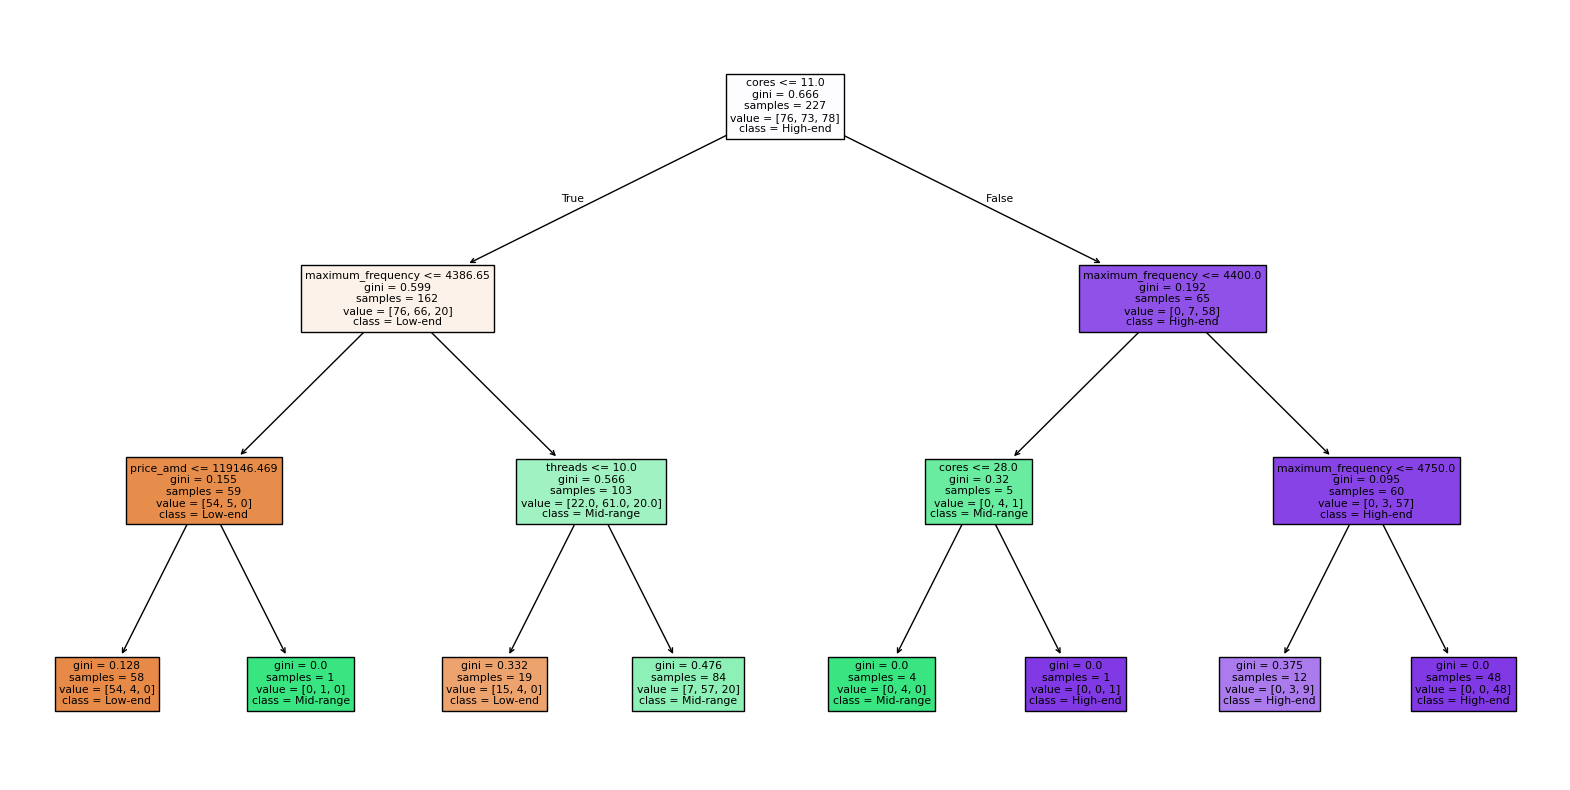

In [ ]:
plt.figure(figsize=(20, 10))

plot_tree(
    clf,
    feature_names=X_train.columns,
    class_names=["Low-end", "Mid-range", "High-end"],
    max_depth=5,
    filled=True
)

plt.show()


This cell evaluates the initial Decision Tree model's performance on the test set. It predicts `y_pred` using `clf.predict(X_test)` and then prints the overall accuracy and a detailed classification report, including precision, recall, and F1-score for each class.

In [ ]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8070175438596491
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        19
           1       0.69      0.86      0.77        21
           2       1.00      0.71      0.83        17

    accuracy                           0.81        57
   macro avg       0.84      0.80      0.81        57
weighted avg       0.83      0.81      0.81        57



#### Grid Search for Decision tree

This cell defines a `param_grid` with different `max_depth` and `min_samples_split` values for hyperparameter tuning. It then uses `GridSearchCV` to exhaustively search for the best combination of these parameters for the Decision Tree, evaluating performance with weighted F1-score using 5-fold cross-validation.

In [ ]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_weighted"
)

grid.fit(X_train, y_train)

best_tree = grid.best_estimator_

y_pred = best_tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8070175438596491
              precision    recall  f1-score   support

           0       0.75      0.79      0.77        19
           1       0.75      0.71      0.73        21
           2       0.94      0.94      0.94        17

    accuracy                           0.81        57
   macro avg       0.81      0.81      0.81        57
weighted avg       0.81      0.81      0.81        57



This cell displays the best hyperparameters found by `GridSearchCV`, providing insights into the optimal configuration for the Decision Tree on this dataset.

In [ ]:
grid.best_params_


{'max_depth': 10, 'min_samples_split': 2}

This cell visualizes the Decision Tree optimized by `GridSearchCV`, similar to the initial tree plot but reflecting the best parameters found. The `filled=True` and `rounded=True` arguments enhance readability.

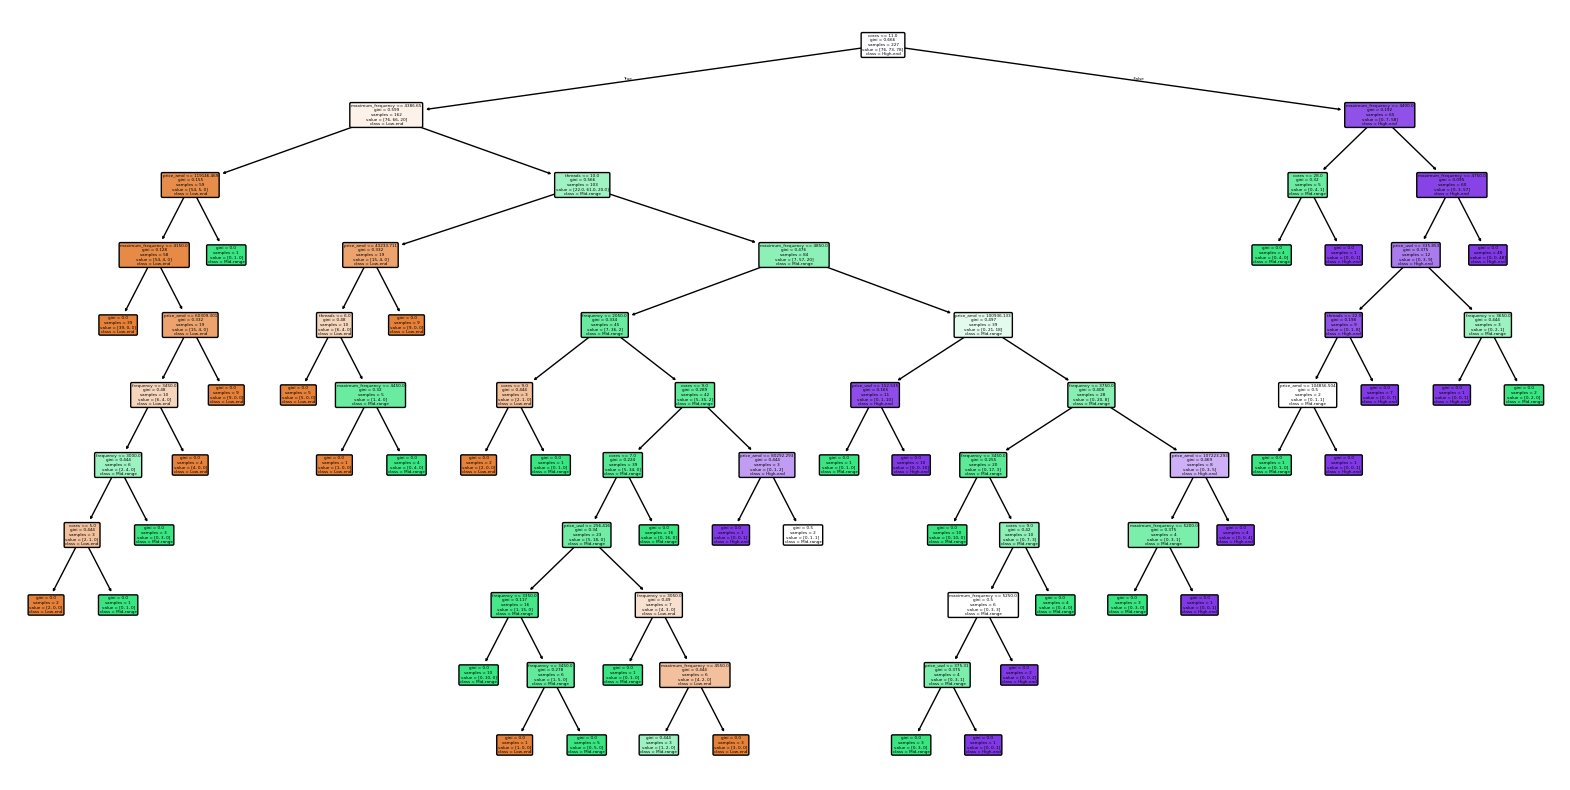

In [ ]:
plt.figure(figsize=(20, 10))

plot_tree(
    best_tree,
    feature_names=X_train.columns,
    class_names=["Low-end", "Mid-range", "High-end"],
    filled=True,
    rounded=True
)

plt.show()


#### Randomized Search for decision tree

This cell sets up `RandomizedSearchCV` to efficiently explore a wider range of hyperparameters (`max_depth`, `min_samples_split`, `min_samples_leaf`) by sampling 30 random combinations. It aims to find a good set of parameters faster than Grid Search.

In [ ]:
param_dist = {
    "max_depth": np.arange(3, 15),
    "min_samples_split": np.arange(2, 20),
    "min_samples_leaf": np.arange(1, 10)
}

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="f1_weighted",
    random_state=42
)

random_search.fit(X_train, y_train)

best_model_random = random_search.best_estimator_


This cell evaluates the Decision Tree model optimized by `RandomizedSearchCV`, similar to the Grid Search evaluation. It makes predictions on the test set and prints the accuracy and a comprehensive classification report.

In [ ]:
y_pred = best_model_random.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7017543859649122
              precision    recall  f1-score   support

           0       0.67      0.74      0.70        19
           1       0.60      0.57      0.59        21
           2       0.88      0.82      0.85        17

    accuracy                           0.70        57
   macro avg       0.71      0.71      0.71        57
weighted avg       0.70      0.70      0.70        57



#### Cross-validation

This cell performs 5-fold cross-validation on the best Decision Tree model (`best_tree`) to assess its generalization performance. It calculates and prints the F1-scores for each fold, as well as the mean F1-score and its standard deviation, providing a more robust estimate of the model's accuracy.

In [ ]:
# Weighted F1-score because we have 3 classes
scorer = make_scorer(f1_score, average="weighted")

# 5-fold cross-validation
cv_scores = cross_val_score(best_tree, X, y, cv=5, scoring=scorer)

print("Cross-validation F1-scores:", cv_scores)
print("Mean F1-score:", cv_scores.mean())
print("Std deviation:", cv_scores.std())


Cross-validation F1-scores: [0.75529829 0.8225957  0.76213112 0.69518919 0.61267007]
Mean F1-score: 0.7295768741703339
Std deviation: 0.07102617362916219


## Clustering

### Task description
This section aims to group similar CPUs together based on their numerical characteristics (like scores, frequencies, core/thread counts) without any predefined categories. This unsupervised learning technique helps uncover natural patterns and segments within the CPU dataset.

### K-means

At first we perform the same actions

Feature selection

In [ ]:
features = [
    "single_core_score",
    "multi_core_score",
    "maximum_frequency",
    "cores",
    "threads"

]

X = data[features]

Scale the data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Than we choose optimal number of clusters

This section aims to determine the optimal number of clusters (k) for K-Means using the `Silhouette Score`. The Silhouette Score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). A higher score indicates better-defined clusters.

In [ ]:
silhouette_scores = {}

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score
    print(f"k = {k}, silhouette score = {score:.3f}")


k = 2, silhouette score = 0.476
k = 3, silhouette score = 0.347
k = 4, silhouette score = 0.363
k = 5, silhouette score = 0.298
k = 6, silhouette score = 0.292
k = 7, silhouette score = 0.296


To find the most optimal number of clusters, we take the `k` with the highest `silhouette score`

In [ ]:
optimal_k = max(silhouette_scores, key=silhouette_scores.get)
print("Optimal number of clusters:", optimal_k)

Optimal number of clusters: 2


This cell initializes and trains the K-Means clustering model with the `optimal_k` found from the silhouette analysis. It then assigns cluster labels to each data point and prints the overall silhouette score for the resulting clusters.

In [ ]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
print("K-Means silhouette score:", kmeans_sil)


K-Means silhouette score: 0.47589646925117146


### DBSCAN

This section introduces DBSCAN, a density-based clustering algorithm. Unlike K-Means, DBSCAN does not require specifying the number of clusters beforehand and can identify noise points. It uses `eps` to define the maximum distance between two samples for one to be considered as in the neighborhood of the other, and `min_samples` as the number of samples in a neighborhood for a point to be considered as a core point. The `fit_predict` method assigns cluster labels, with -1 indicating noise points.

In [ ]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

This section calculates the silhouette score for the DBSCAN clustering results. It's important to note that silhouette score is calculated only for the data points that are assigned to clusters (i.e., not noise points, labeled as -1) and if there are more than one cluster found, as silhouette score requires at least two clusters to be meaningful.

In [ ]:
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    dbscan_sil = silhouette_score(
        X_scaled[mask], dbscan_labels[mask]
    )
else:
    dbscan_sil = -1

print("DBSCAN silhouette score:", dbscan_sil)


DBSCAN silhouette score: 0.41164209522576


This cell adds the `kmeans_labels` as a new 'cluster' column to the original `data` DataFrame. It then groups the data by 'cluster' and calculates the mean of the selected features for each cluster, providing a summary of the typical characteristics of CPUs within each cluster.

In [ ]:
data["cluster"] = kmeans_labels

cluster_summary = data.groupby("cluster")[features].mean()
print(cluster_summary)

         single_core_score  multi_core_score  maximum_frequency      cores  \
cluster                                                                      
0              2658.309524      15321.559524          5230.8500  16.190476   
1              1717.740000       6781.915000          4469.3175   6.520000   

           threads  
cluster             
0        26.095238  
1        12.590000  


This section utilizes Principal Component Analysis (PCA) to reduce the dimensionality of the clustered data, making it easier to visualize the clusters in a 2D scatter plot.

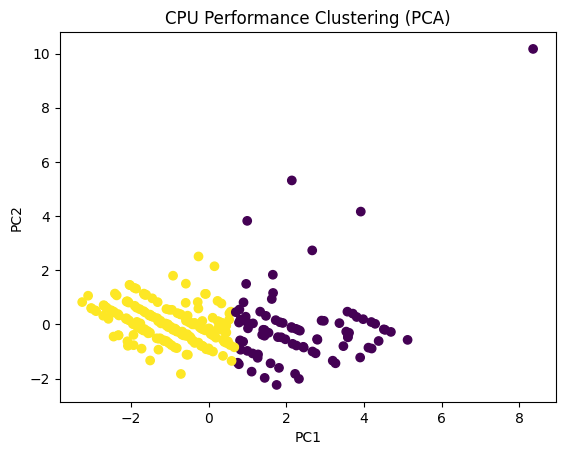

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("CPU Performance Clustering (PCA)")
plt.show()


This cell calculates and displays the PCA loadings, which represent the contribution of each original feature to each principal component. The loadings help interpret what each principal component primarily represents (e.g., if PC1 has high loadings for 'cores' and 'threads', it signifies 'parallel processing capability').

In [ ]:
# scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# fit PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# loadings
loadings = pd.DataFrame(pca.components_.T, index=features, columns=['PC1','PC2'])
print(loadings)


                        PC1       PC2
single_core_score  0.443912 -0.452121
multi_core_score   0.506899 -0.165942
maximum_frequency  0.430180 -0.408179
cores              0.446700  0.490251
threads            0.401745  0.600911


In [ ]:
print(pca.explained_variance_ratio_)

[0.70694963 0.22378764]


## Best ML Model Selection

We evaluated both **supervised and unsupervised models** on the CPU dataset, but these models serve different purposes, so their metrics are not directly comparable.

* **Unsupervised learning (clustering):**
    * Models: K-Means, DBSCAN
    * Goal: group CPUs based on features (cores, threads, frequency, scores) without using price labels.
    * Metric: **Silhouette Score** – measures how well clusters are separated and cohesive.
    * Result: K-Means achieved a silhouette score of 0.476, slightly better than DBSCAN (0.412), indicating clearer cluster structure.

* **Supervised learning (regression):**
    * Models: Ridge Regression, Polynomial Ridge Regression, Support Vector Regression
    * Goal: predict CPU prices based on features.
    * Metrics: **MSE, RMSE, MAE, R²** – measure prediction accuracy.
    * Result:
        * Ridge Regression → MSE = 12,974.43, RMSE = 113.91, MAE = 84.31, R² = 0.319
        * Polynomial Ridge Regression → MSE = 12,266.45, RMSE = 110.75, MAE = 83.42, R² = 0.318

**Interpretation:**

* Although the metrics are different, we compare models based on **which task they solve better**:
    * For grouping CPUs → **K-Means** is preferred due to clearer clusters.
    * For predicting CPU prices → **Polynomial Ridge Regression** performs best, capturing non-linear patterns while controlling overfitting.
* Decision tree classification was evaluated separately with cross-validation (mean F1-score 0.737) and can be further tuned for classification tasks.

**Conclusion:**

* Supervised and unsupervised models cannot be compared directly by the same metrics, but by the **effectiveness in their respective tasks**. Polynomial Ridge Regression is selected for price prediction, while K-Means is preferred for clustering CPUs.


## Results Explanation

The best-performing model on the CPU dataset was **Polynomial Ridge Regression**, achieving the lowest error values (MSE = 12,266.45, RMSE = 110.75, MAE = 83.42) and the highest R² score (0.32). This indicates that the model explains approximately **32% of the variance in CPU prices** based on numerical hardware features such as core count, thread count, frequency, and benchmark scores.

The improved performance over standard Ridge Regression shows that **CPU pricing follows non-linear patterns**, which were better captured by second-degree polynomial features. Ridge regularization helped control overfitting, ensuring better generalization to unseen data.



## Implications and Applications

This model can be used for **CPU price prediction**, **market analysis**, and **performance-based product comparison**. While performance is moderate, it reflects the complexity of pricing factors beyond hardware specifications, such as brand value and market demand. Further improvements could be achieved through additional feature engineering and more advanced models.
